# 12 — Cinq modèles PFAS avec HGT transductif sur **graphe puits**

Améliorations par rapport au notebook 11, guidées par l'analyse de son run complet
(HGT 0.8425 vs XGBoost 0.9059, split par puits) :

1. **Graphe au niveau puits** — le diagnostic du NB 11 : 71,9 % des voisins kNN d'un
   échantillon sont des prélèvements du **même puits** (4,1 échantillons/puits aux mêmes
   coordonnées) ; les 8 voisins ne couvraient que ~2,2 puits distincts, et seulement 17,3 %
   des arêtes kNN d'un puits test pointaient vers le train. Ici : nœuds `well` (~11 300),
   kNN calculé sur les **puits uniques**, les échantillons se connectent à leur puits.
   Le voisinage couvre enfin k puits réellement distincts (~60 % en train).
2. **Bandes de distance comme types de relation** — `HGTConv` ne prend pas d'attributs
   d'arête ; on encode la distance en séparant les arêtes puits↔puits en relations
   `near_0_2km` / `near_2_10km` / `near_10_30km` (attention distincte par bande).
   Idem pour les sites GeoTracker (`near_source_10km` / `near_source_50km`).
3. **Features spatiales étiquetées** (optionnel, `ADD_SPATIAL_LABEL_FEATURES`) — moyenne
   pondérée par la distance des labels des puits **d'entraînement** voisins (leave-one-well-out,
   aucune fuite val/test), fournie à TOUS les modèles pour une comparaison équitable.
4. **Early stopping** (patience 50 sur l'AUC val) — le NB 11 plafonnait dès l'epoch ~60
   et brûlait 240 epochs pour rien.
5. **GPU réactivé** (`FORCE_CPU=False`) — le run 11 a tourné sur CPU, le timeout Optuna
   (1 800 s) n'a probablement laissé passer que quelques trials.

Le reste (cibles EPA 2024, split par puits, HPO sur AUC val, résidus+LayerNorm+jumping
knowledge, stacking honnête sur validation) est repris du NB 11.

In [1]:
# --- Detection de l'environnement ---
import sys, importlib.util, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

if IN_COLAB:
    print("Google Colab detecte — installation des dependances...")
    import torch
    tv = torch.__version__.split("+")[0]
    cu = ("cu" + torch.version.cuda.replace(".", "")) if torch.version.cuda else "cpu"
    print(f"  torch={tv} | backend={cu}")
    _pip("torch_geometric")
    _pip("pyg_lib", "torch_scatter", "torch_sparse",
         "-f", f"https://data.pyg.org/whl/torch-{tv}+{cu}.html")
    _pip("xgboost", "optuna", "shap", "seaborn", "pyarrow", "networkx")
    print("Installation terminee.")
else:
    print("Environnement local — verification des librairies (aucune installation).")
    for m in ["torch", "torch_geometric", "xgboost", "optuna", "shap"]:
        ok = importlib.util.find_spec(m) is not None
        print(f"  {m:16s}: {'OK' if ok else 'MANQUANT'}")

Google Colab detecte — installation des dependances...
  torch=2.11.0 | backend=cu128
Installation terminee.


In [2]:
import warnings, json, pickle, time, os, zipfile
from pathlib import Path
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    GroupShuffleSplit, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve, accuracy_score,
    recall_score, precision_score, balanced_accuracy_score)
from sklearn.neighbors import NearestNeighbors, BallTree

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# GPU reactive (le NB11 a tourne sur CPU). Repassez FORCE_CPU=True si le GPU
# Colab plante (CUDA device-side assert), puis Redemarrer la session.
FORCE_CPU = False
if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear as PyGLinear
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("PyTorch Geometric indisponible :", e)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports OK | PyG disponible :", TORCH_GEOMETRIC_AVAILABLE)

Imports OK | PyG disponible : True


In [3]:
# ════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE
# ════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42

# --- Donnees ---
DATA_FILENAME      = "CA-PFAS-ASGWS_v2.parquet"
MISSING_THRESHOLD  = 0.40
DROP_LOCATION      = False
DEV_SUBSAMPLE      = None    # int (ex 5000) pour un test rapide

# --- Split ---
TEST_SIZE = 0.20
VAL_SIZE  = 0.25             # part du reste -> 60/20/20
GROUP_SPLIT_BY_WELL = True   # aucun puits (gm_well_id) a cheval train/test

# --- Graphe PUITS (transductif) ---
WELL_KNN_K       = 10                  # k plus proches PUITS (uniques) par puits
WELL_BANDS_KM    = (2.0, 10.0, 30.0)   # bandes de distance -> relations distinctes
REGION_COL       = "sgma_subbasin_name"
USE_GEO_CLUSTER  = True               # hubs KMeans redondants avec kNN multi-bandes
N_GEO_CLUSTERS   = 20
USE_SOURCE_NODES = True
SITES_FILENAME   = "geotracker_pfas_investigation_sites.csv"
SOURCE_BANDS_KM  = (10.0, 50.0)        # bandes puits->site (site le + proche tjrs garde)
SOURCE_KMAX      = 6

# --- Features spatiales etiquetees (fournies a TOUS les modeles) ---
ADD_SPATIAL_LABEL_FEATURES = False      # moyenne ponderee des labels des puits TRAIN voisins
K_LABEL_NEIGHBORS          = 10        # (leave-one-well-out, aucune fuite val/test)

# --- Optuna ---
OPTUNA_MODE = "FULL"
_TRIALS = {
    "FAST": {"rf": 8,  "xgb": 10, "hgt": 6,  "fusion": 8},
    "FULL": {"rf": 40, "xgb": 60, "hgt": 25, "fusion": 20},
}[OPTUNA_MODE]
OPTUNA_TIMEOUT = {"FAST": 300, "FULL": 1800}[OPTUNA_MODE]

# --- HGT ---
EPOCHS_HGT  = {"FAST": 60, "FULL": 300}[OPTUNA_MODE]
ES_PATIENCE = 50            # early stopping (epochs sans amelioration d'AUC val)

# --- Section finale : evaluation honnete ---
RUN_SPATIAL_CV = True    # CV spatiale par blocs k=8 (long). True pour le rendu final.
SPATIAL_CV_K   = 8

# --- Reglementation EPA 2024 NPDWR ---
EPA2024_MCLS = {"PFOA_ngL": 4.0, "PFOS_ngL": 4.0, "PFNA_ngL": 10.0,
                "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0}
HI_REFS = {"PFNA_ngL": 10.0, "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0, "PFBS_ngL": 2000.0}

np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.manual_seed(RANDOM_STATE)
except Exception as _e:
    print("Avertissement CUDA :", _e); device = torch.device("cpu")

OUT_DIR    = Path("outputs_notebook_graphe_puits")
FIG_DIR    = OUT_DIR / "figures"
RES_DIR    = OUT_DIR / "results"
MODELS_DIR = OUT_DIR / "models"
for d in (FIG_DIR, RES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

EARTH_KM = 6371.0
print(f"Mode Optuna : {OPTUNA_MODE} | trials={_TRIALS} | epochs HGT={EPOCHS_HGT} (patience {ES_PATIENCE})")
print(f"Split par puits : {GROUP_SPLIT_BY_WELL} | Device : {device}")

Mode Optuna : FULL | trials={'rf': 40, 'xgb': 60, 'hgt': 25, 'fusion': 20} | epochs HGT=300 (patience 50)
Split par puits : True | Device : cuda


In [4]:
GITHUB_REPO_RAW = ("https://raw.githubusercontent.com/dnwiloic/pfas-gnn/"
                   "d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data")

def locate_dataset(filename):
    candidates = [Path(filename), Path("data/processed")/filename,
                  Path("../data/processed")/filename,
                  Path("data/raw/contamination")/filename,
                  Path("../data/raw/contamination")/filename,
                  Path("/content")/filename, Path("/content/drive/MyDrive")/filename]
    for c in candidates:
        if c.exists():
            return c
    # Telechargement automatique depuis GitHub (repo public dnwiloic/pfas-gnn)
    try:
        import urllib.request
        url = f"{GITHUB_REPO_RAW}/{filename}"
        dest = Path(filename)
        print(f"Fichier local introuvable -> telechargement depuis GitHub : {url}")
        urllib.request.urlretrieve(url, dest)
        if dest.exists() and dest.stat().st_size > 0:
            print(f"  OK -> {dest} ({dest.stat().st_size/1e6:.1f} Mo)")
            return dest
    except Exception as e:
        print(f"  Echec du telechargement GitHub : {e}")
    if IN_COLAB:
        from google.colab import files
        print(f"Veuillez televerser '{filename}' :")
        up = files.upload()
        return Path(list(up.keys())[0])
    raise FileNotFoundError(f"{filename} introuvable — placez-le a cote du notebook.")

DATA_PATH = locate_dataset(DATA_FILENAME)
df = pd.read_parquet(DATA_PATH)
if DEV_SUBSAMPLE:
    df = df.sample(n=min(DEV_SUBSAMPLE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[DEV] sous-echantillon : {len(df)} lignes")
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes  (source: {DATA_PATH})")

Fichier local introuvable -> telechargement depuis GitHub : https://raw.githubusercontent.com/dnwiloic/pfas-gnn/d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data/CA-PFAS-ASGWS_v2.parquet
  OK -> CA-PFAS-ASGWS_v2.parquet (4.4 Mo)
Dataset : 46,338 lignes x 217 colonnes  (source: CA-PFAS-ASGWS_v2.parquet)


In [5]:
sites_df = None
if USE_SOURCE_NODES:
    try:
        sp = locate_dataset(SITES_FILENAME)
        sites_df = pd.read_csv(sp).dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
        print(f"Sites GeoTracker charges : {len(sites_df)}  (source: {sp})")
    except Exception as e:
        USE_SOURCE_NODES = False
        print(f"Sites GeoTracker indisponibles -> noeuds 'source' desactives ({e})")
else:
    print("Noeuds 'source' desactives (USE_SOURCE_NODES=False)")

Fichier local introuvable -> telechargement depuis GitHub : https://raw.githubusercontent.com/dnwiloic/pfas-gnn/d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data/geotracker_pfas_investigation_sites.csv
  OK -> geotracker_pfas_investigation_sites.csv (0.1 Mo)
Sites GeoTracker charges : 463  (source: geotracker_pfas_investigation_sites.csv)


In [6]:
def compute_target_epa2024(d):
    exceeded = pd.Series(False, index=d.index)
    for col, mcl in EPA2024_MCLS.items():
        if col in d.columns:
            exceeded |= d[col].fillna(0) > mcl
    hi = sum(d[c].fillna(0) / r for c, r in HI_REFS.items() if c in d.columns)
    exceeded |= hi > 1.0
    return exceeded.astype(int)

df["target"] = compute_target_epa2024(df)
n_pos = int(df["target"].sum()); n_neg = len(df) - n_pos
print(f"Positifs (>= MCL ou HI>1) : {n_pos:,}  ({100*n_pos/len(df):.2f}%)")
print(f"Negatifs (< MCL)          : {n_neg:,}  ({100*n_neg/len(df):.2f}%)")

Positifs (>= MCL ou HI>1) : 21,154  (45.65%)
Negatifs (< MCL)          : 25,184  (54.35%)


In [7]:
# ── Sources de fuite (identiques NB09/10/11) ────────────────────────────
LEAK_SUFFIXES      = ("_ngL",)
LEAK_BOOL_SUFFIXES = ("_detected",)
LEAK_PREFIXES      = ("label_",)
LEAK_EXACT = {
    "sum_pfas_ngL", "pfas_class_assignment", "gm_well_id", "collection_date",
    "target", "target_sum_gt70", "gm_dataset_name", "gldas_dist_km",
}
DROP_REDUNDANT = {"dwr_basin", "sgma_basin_name", "sgma_subbasin_name"}

if "collection_date" in df.columns:
    _dt = pd.to_datetime(df["collection_date"], errors="coerce")
    df["year"]   = _dt.dt.year
    df["month"]  = _dt.dt.month
    df["season"] = ((_dt.dt.month % 12) // 3 + 1).astype("float")

_miss = df.isna().mean()
HIGH_MISSING_DROP = set(_miss[_miss > MISSING_THRESHOLD].index)

LOCATION_FEATURES = {"latitude", "longitude", "county", "regional_board",
                     "dwr_region", "sgma_region_office"}
loc_drop = LOCATION_FEATURES if DROP_LOCATION else set()

CATEGORICAL_CANDIDATES = ["county", "regional_board", "dwr_region", "gm_well_category",
                          "sgma_region_office", "nearest_geotracker_type", "soil_texture_class"]
cat_cols = [c for c in CATEGORICAL_CANDIDATES
            if c in df.columns and c not in loc_drop and c not in HIGH_MISSING_DROP]

def _is_leak(c):
    return (any(c.endswith(s) for s in LEAK_SUFFIXES)
            or any(c.endswith(s) for s in LEAK_BOOL_SUFFIXES)
            or any(c.startswith(p) for p in LEAK_PREFIXES)
            or c in LEAK_EXACT)

num_cols = [c for c in df.columns
            if df[c].dtype.kind in ("f", "i", "u")
            and not _is_leak(c) and c not in HIGH_MISSING_DROP
            and c not in DROP_REDUNDANT and c not in loc_drop and c not in cat_cols]

feature_names = num_cols + cat_cols
print(f"Features numeriques : {len(num_cols)} | categorielles : {len(cat_cols)} | TOTAL : {len(feature_names)}")
assert not any(_is_leak(c) for c in feature_names), "FUITE detectee dans les features !"
print("Verification anti-fuite : OK")

Features numeriques : 96 | categorielles : 7 | TOTAL : 103
Verification anti-fuite : OK


## Split, structures puits

Chaque échantillon est rattaché à son puits (`winv`). Les coordonnées, effectifs et
appartenance train/val/test sont calculés **au niveau puits** — c'est la maille du graphe.

In [8]:
X = df[feature_names].copy()
y = df["target"].values
idx_all = np.arange(len(df))

# ── Structures puits ─────────────────────────────────────────────────────
wid_all = np.asarray(df["gm_well_id"].astype(str)) if "gm_well_id" in df.columns \
          else np.asarray([f"w{i}" for i in idx_all])
wcats, winv = np.unique(wid_all, return_inverse=True)
n_wells = len(wcats)
wcnt = np.bincount(winv).astype(float)
well_coords = np.zeros((n_wells, 2))
np.add.at(well_coords[:, 0], winv, df["latitude"].values)
np.add.at(well_coords[:, 1], winv, df["longitude"].values)
well_coords /= wcnt[:, None]
print(f"{len(df):,} echantillons -> {n_wells:,} puits ({len(df)/n_wells:.2f} ech/puits)")

# ── Split ────────────────────────────────────────────────────────────────
if GROUP_SPLIT_BY_WELL:
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    idx_tmp, idx_test = next(gss.split(idx_all, y, groups=wid_all))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
    a, b = next(gss2.split(idx_tmp, y[idx_tmp], groups=wid_all[idx_tmp]))
    idx_train, idx_val = idx_tmp[a], idx_tmp[b]
    assert not (set(wid_all[idx_train]) & set(wid_all[idx_test])), "puits a cheval train/test !"
    print(f"Split PAR PUITS — puits uniques : train {len(np.unique(winv[idx_train])):,} | "
          f"val {len(np.unique(winv[idx_val])):,} | test {len(np.unique(winv[idx_test])):,}")
else:
    idx_tmp, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                         stratify=y, random_state=RANDOM_STATE)
    idx_train, idx_val = train_test_split(idx_tmp, test_size=VAL_SIZE,
                                          stratify=y[idx_tmp], random_state=RANDOM_STATE)
    print("Split aleatoire stratifie")

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f"Train: {len(idx_train):,} ({100*y_train.mean():.1f}% +) | "
      f"Val: {len(idx_val):,} ({100*y_val.mean():.1f}% +) | "
      f"Test: {len(idx_test):,} ({100*y_test.mean():.1f}% +)")

# statut de chaque puits (train prioritaire si split aleatoire melange un puits)
well_split = np.full(n_wells, 2)                    # 2=test par defaut
well_split[np.unique(winv[idx_val])] = 1
well_split[np.unique(winv[idx_train])] = 0
print("Puits par statut (0=train,1=val,2=test) :", np.bincount(well_split, minlength=3))

46,338 echantillons -> 11,333 puits (4.09 ech/puits)
Split PAR PUITS — puits uniques : train 6,799 | val 2,267 | test 2,267
Train: 27,894 (46.5% +) | Val: 9,264 (45.0% +) | Test: 9,180 (43.8% +)
Puits par statut (0=train,1=val,2=test) : [6799 2267 2267]


## Features spatiales étiquetées (leave-one-well-out, train uniquement)

Pour chaque puits : moyenne pondérée par l'inverse de la distance des taux de contamination
des `K_LABEL_NEIGHBORS` puits **d'entraînement** les plus proches (son propre puits exclu),
plus la distance au puits train le plus proche. Aucun label val/test n'entre dans le calcul.
Ces deux features sont données à **tous** les modèles (tabulaires et HGT) — la comparaison
reste équitable. L'AUC de la feature seule, imprimée ci-dessous, sert de baseline « spatial pur ».

In [9]:
if ADD_SPATIAL_LABEL_FEATURES:
    tr_wells = np.unique(winv[idx_train])
    lab_sum = np.zeros(n_wells); lab_cnt = np.zeros(n_wells)
    np.add.at(lab_sum, winv[idx_train], y[idx_train])
    np.add.at(lab_cnt, winv[idx_train], 1)
    tw_label = lab_sum[tr_wells] / lab_cnt[tr_wells]      # taux de contamination du puits train

    ttree = BallTree(np.radians(well_coords[tr_wells]), metric="haversine")
    K2 = min(K_LABEL_NEIGHBORS + 1, len(tr_wells))
    d_, j_ = ttree.query(np.radians(well_coords), k=K2)
    d_km = d_ * EARTH_KM
    own = tr_wells[j_] == np.arange(n_wells)[:, None]     # exclut son propre puits (LOO)
    w_ = 1.0 / (d_km + 0.5); w_[own] = 0.0
    nbr_label = (w_ * tw_label[j_]).sum(1) / (w_.sum(1) + 1e-9)
    d_masked = np.where(own, np.inf, d_km)
    dist_train = np.log1p(d_masked.min(1))

    spatial_label_feats = np.column_stack([nbr_label[winv], dist_train[winv]]).astype("float32")
    SPATIAL_LABEL_NAMES = ["nbr_train_label_wmean", "log_dist_nearest_train_well_km"]
    auc_solo = roc_auc_score(y_test, spatial_label_feats[idx_test, 0])
    print(f"Baseline 'spatial pur' — AUC test de nbr_train_label_wmean seule : {auc_solo:.4f}")
else:
    spatial_label_feats = None; SPATIAL_LABEL_NAMES = []
    print("Features spatiales etiquetees desactivees")

Features spatiales etiquetees desactivees


In [10]:
# ── Preprocesseur (fit sur train, transform sur TOUT le dataset) ────────
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1, encoded_missing_value=-1)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

preprocessor.fit(X.iloc[idx_train])
X_all_proc = preprocessor.transform(X)
proc_cols = num_cols + cat_cols
if spatial_label_feats is not None:
    X_all_proc = np.concatenate([X_all_proc, spatial_label_feats], axis=1)
    proc_cols = proc_cols + SPATIAL_LABEL_NAMES

scaler = StandardScaler().fit(X_all_proc[idx_train])
X_all_sc = scaler.transform(X_all_proc)
X_train_proc, X_val_proc, X_test_proc = (X_all_proc[i] for i in (idx_train, idx_val, idx_test))
print(f"X_all_proc {X_all_proc.shape} ({len(proc_cols)} features, "
      f"dont {len(SPATIAL_LABEL_NAMES)} spatiales etiquetees)")

X_all_proc (46338, 103) (103 features, dont 0 spatiales etiquetees)


In [11]:
RESULTS = {}

def evaluate(name, y_true, y_pred, y_proba, store=True, show=True):
    m = {"name": name,
         "roc_auc": roc_auc_score(y_true, y_proba),
         "avg_precision": average_precision_score(y_true, y_proba),
         "accuracy": accuracy_score(y_true, y_pred),
         "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall": recall_score(y_true, y_pred),
         "f1": f1_score(y_true, y_pred)}
    if show:
        print(f"{'─'*52}\n  {name}\n{'─'*52}")
        for k in ["roc_auc","avg_precision","recall","precision","f1","balanced_accuracy","accuracy"]:
            print(f"  {k:20s}: {m[k]:.4f}")
    if store:
        RESULTS[name] = {"metrics": m, "y_pred": np.asarray(y_pred), "y_proba": np.asarray(y_proba)}
    return m

def plot_confusion(name, y_true, y_pred, fname):
    fig, ax = plt.subplots(figsize=(4.3, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["< MCL (0)", ">= MCL (1)"],
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion — {name}")
    plt.tight_layout(); savefig(fig, fname); plt.show()

def optuna_history_fig(study, title, fname, color="steelblue"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study.trials if t.value is not None]
    best = [max(vals[:i+1]) for i in range(len(vals))]
    axes[0].plot(vals, "o", alpha=.4, color=color, ms=5, label="Trial")
    axes[0].plot(best, "-", color="black", lw=2, label="Meilleur cumule")
    axes[0].set(xlabel="Trial", ylabel="Score objectif (AUC val)", title=f"{title} — historique Optuna")
    axes[0].legend(); axes[0].grid(alpha=.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color=color)
        axes[1].set(xlabel="Importance relative", title="Importance des hyperparametres")
    except Exception:
        axes[1].text(.5, .5, "Pas assez de trials", ha="center", transform=axes[1].transAxes)
    plt.tight_layout(); savefig(fig, fname); plt.show()

scale_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Utilitaires prets. scale_pos_weight =", round(scale_pos, 3))

Utilitaires prets. scale_pos_weight = 1.152


## Modèle 1 — Random Forest (référence tabulaire)

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleur AUC-CV : 0.9804 | params : {'n_estimators': 600, 'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 6}


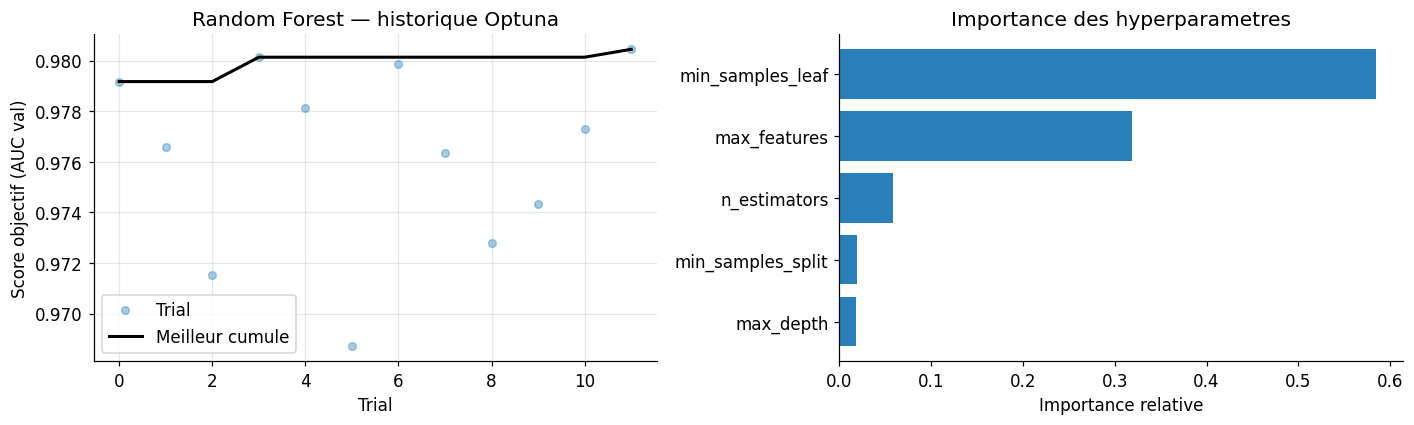

────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────
  roc_auc             : 0.8910
  avg_precision       : 0.8763
  recall              : 0.7280
  precision           : 0.8589
  f1                  : 0.7881
  balanced_accuracy   : 0.8174
  accuracy            : 0.8284


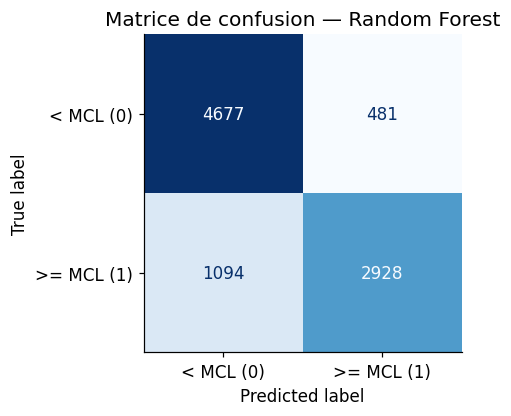

In [12]:
def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth=trial.suggest_categorical("max_depth", [None, 15, 20, 30]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    sc = cross_val_score(RandomForestClassifier(**params), X_train_proc, y_train,
                         cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                         scoring="roc_auc", n_jobs=1)
    return sc.mean()

study_rf = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.enqueue_trial({"n_estimators": 500, "max_depth": None, "max_features": "sqrt",
                        "min_samples_leaf": 2, "min_samples_split": 2})
study_rf.optimize(objective_rf, n_trials=_TRIALS["rf"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-CV :", round(study_rf.best_value, 4), "| params :", study_rf.best_params)
optuna_history_fig(study_rf, "Random Forest", "fig01_optuna_rf.png", color="#2980b9")

best_rf_params = {**study_rf.best_params, "class_weight": "balanced",
                  "n_jobs": -1, "random_state": RANDOM_STATE}
rf = RandomForestClassifier(**best_rf_params).fit(X_train_proc, y_train)
y_pred_rf  = rf.predict(X_test_proc)
y_proba_rf = rf.predict_proba(X_test_proc)[:, 1]
m_rf = evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)
plot_confusion("Random Forest", y_test, y_pred_rf, "fig02_rf_confusion.png")

## Modèle 2 — XGBoost (référence tabulaire)

  0%|          | 0/60 [00:00<?, ?it/s]

Meilleur AUC-val : 0.8794 | params : {'n_estimators': 1100, 'learning_rate': 0.06542753299106235, 'max_depth': 9, 'subsample': 0.8086998925784614, 'colsample_bytree': 0.8401522593572472, 'min_child_weight': 6, 'gamma': 0.4507328559480873, 'reg_alpha': 3.2988676431648466e-07, 'reg_lambda': 1.4720361172033253e-06}


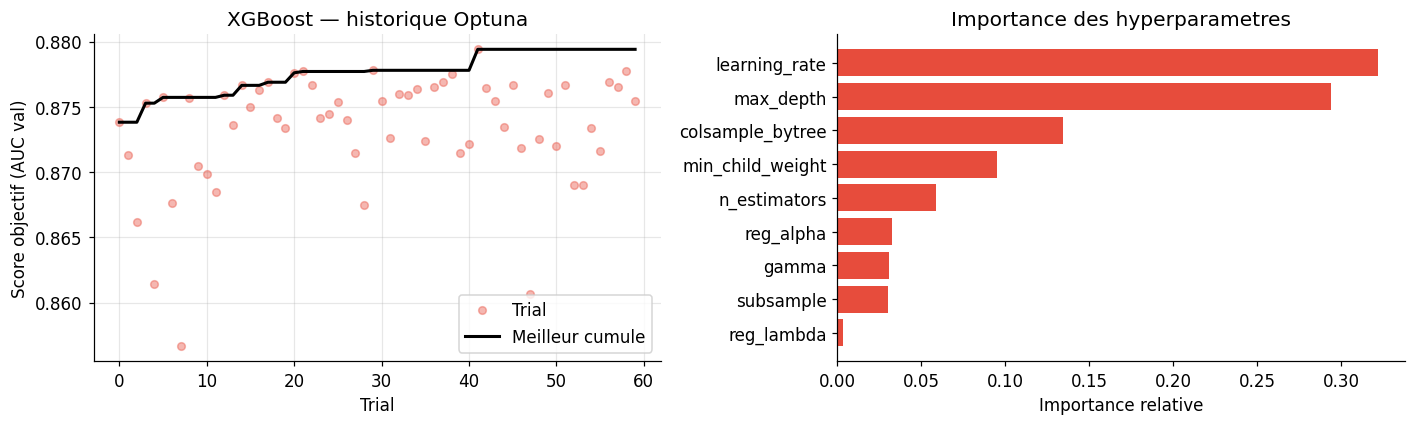

Best iteration : 88
────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  roc_auc             : 0.9059
  avg_precision       : 0.8911
  recall              : 0.7541
  precision           : 0.8484
  f1                  : 0.7985
  balanced_accuracy   : 0.8245
  accuracy            : 0.8332


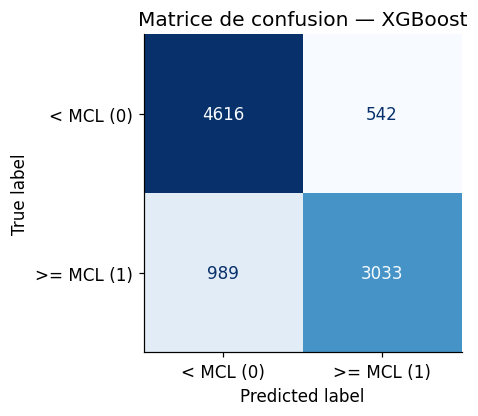

In [13]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 2000, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        scale_pos_weight=scale_pos, tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
    model = xgb.XGBClassifier(**params, early_stopping_rounds=40)
    model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val_proc)[:, 1])

study_xgb = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study_xgb.enqueue_trial({"n_estimators": 1000, "learning_rate": 0.05, "max_depth": 6,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3, "gamma": 0.1,
    "reg_alpha": 0.1, "reg_lambda": 1.0})
study_xgb.optimize(objective_xgb, n_trials=_TRIALS["xgb"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-val :", round(study_xgb.best_value, 4), "| params :", study_xgb.best_params)
optuna_history_fig(study_xgb, "XGBoost", "fig03_optuna_xgb.png", color="#e74c3c")

best_xgb_params = {**study_xgb.best_params, "scale_pos_weight": scale_pos,
                   "tree_method": "hist", "n_jobs": -1, "random_state": RANDOM_STATE,
                   "eval_metric": "auc", "verbosity": 0}
xgb_model = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
xgb_model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
print(f"Best iteration : {xgb_model.best_iteration}")
y_pred_xgb  = xgb_model.predict(X_test_proc)
y_proba_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
m_xgb = evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
plot_confusion("XGBoost", y_test, y_pred_xgb, "fig04_xgb_confusion.png")

## Graphe **puits** transductif

Nœuds : `sample` (46 k, features tabulaires), `well` (~11 k, moyenne des features de ses
prélèvements + log effectif), `subbasin`, `source` (GeoTracker). Le kNN est calculé sur les
**puits uniques** (distance haversine) et découpé en bandes de distance — chaque bande est
une relation distincte pour l'attention du HGT. Les échantillons d'un même puits communiquent
via leur nœud `well` (plus besoin d'arêtes same-well).

In [14]:
if TORCH_GEOMETRIC_AVAILABLE:
    # ── Noeuds WELL : moyenne des features standardisees + log effectif ──
    well_x = np.zeros((n_wells, X_all_sc.shape[1]), "float64")
    np.add.at(well_x, winv, X_all_sc)
    well_x = (well_x / wcnt[:, None]).astype("float32")
    well_x = np.hstack([well_x, np.log1p(wcnt)[:, None].astype("float32")])

    # ── kNN puits<->puits par bandes de distance ─────────────────────────
    wtree = BallTree(np.radians(well_coords), metric="haversine")
    Kq = min(WELL_KNN_K + 1, n_wells)
    wd, wi = wtree.query(np.radians(well_coords), k=Kq)
    wd_km = wd * EARTH_KM
    bands = list(WELL_BANDS_KM)
    band_edges = [[[], []] for _ in bands]
    for i in range(n_wells):
        added = False
        for jc in range(Kq):
            j = int(wi[i, jc])
            if j == i:
                continue
            dk = wd_km[i, jc]
            b = next((k for k, hi in enumerate(bands) if dk <= hi), None)
            if b is None:                       # au-dela de la derniere bande :
                if added:                       # on garde quand meme le puits le plus
                    continue                    # proche (connectivite), dans la
                b = len(bands) - 1              # derniere bande
            band_edges[b][0].append(i); band_edges[b][1].append(j)
            added = True

    # ── Sites GeoTracker rattaches aux PUITS, par bandes ─────────────────
    SOURCE_X, src_edges = None, {}
    if USE_SOURCE_NODES and sites_df is not None:
        _sc = sites_df[["latitude", "longitude"]].values.astype("float64")
        src_tree = BallTree(np.radians(_sc), metric="haversine")
        _st = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)\
              .fit_transform(sites_df[["site_type"]].astype(str)).ravel() if "site_type" in sites_df else np.zeros(len(_sc))
        _z = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-9)
        SOURCE_X = np.column_stack([_z(_sc[:, 0]), _z(_sc[:, 1]), _z(_st)]).astype("float32")
        sd, si = src_tree.query(np.radians(well_coords), k=min(SOURCE_KMAX, len(_sc)))
        sd_km = sd * EARTH_KM
        sbands = list(SOURCE_BANDS_KM)
        src_edges = {k: [[], []] for k in range(len(sbands))}
        for i in range(n_wells):
            for jc in range(sd.shape[1]):
                dk = sd_km[i, jc]
                b = next((k for k, hi in enumerate(sbands) if dk <= hi), None)
                if b is None:
                    if jc == 0:                 # site le plus proche toujours garde
                        b = len(sbands) - 1
                    else:
                        continue
                src_edges[b][0].append(i); src_edges[b][1].append(int(si[i, jc]))

    # ── Noeuds SUBBASIN (rattaches aux puits) ────────────────────────────
    _sub = (df[REGION_COL].fillna("UNKNOWN").astype(str).values
            if REGION_COL in df.columns else np.array(["ALL"] * len(df)))
    well_sub = pd.Series(_sub).groupby(winv).first().values
    scats, sinv = np.unique(well_sub, return_inverse=True)
    sfeat = np.zeros((len(scats), 3), "float32")
    for k in range(len(scats)):
        m = sinv == k
        sfeat[k] = [well_coords[m, 0].mean(), well_coords[m, 1].mean(), np.log1p(m.sum())]
    sfeat = (sfeat - sfeat.mean(0)) / (sfeat.std(0) + 1e-9)

    # ── Assemblage HeteroData + masques ──────────────────────────────────
    data = HeteroData(); n = len(df)
    data["sample"].x = torch.FloatTensor(X_all_sc)
    data["sample"].y = torch.LongTensor(y)
    for name_, idx_ in [("train_mask", idx_train), ("val_mask", idx_val), ("test_mask", idx_test)]:
        m = torch.zeros(n, dtype=torch.bool); m[idx_] = True
        data["sample"][name_] = m
    sr = np.arange(n)
    data["well"].x = torch.FloatTensor(well_x)
    data["sample", "from_well", "well"].edge_index = torch.tensor(np.stack([sr, winv]), dtype=torch.long)
    data["well", "has_sample", "sample"].edge_index = torch.tensor(np.stack([winv, sr]), dtype=torch.long)
    _prev = 0.0
    for k, hi in enumerate(bands):
        s_, t_ = band_edges[k]
        if s_:
            e = np.stack([np.array(s_), np.array(t_)])
            e = np.concatenate([e, e[::-1]], 1)          # non oriente
            rel = f"near_{int(_prev)}_{int(hi)}km"
            data["well", rel, "well"].edge_index = torch.tensor(e, dtype=torch.long)
        _prev = hi
    if SOURCE_X is not None:
        data["source"].x = torch.FloatTensor(SOURCE_X)
        _prev = 0.0
        for k, hi in enumerate(SOURCE_BANDS_KM):
            s_, t_ = src_edges.get(k, [[], []])
            if s_:
                e = np.stack([np.array(s_), np.array(t_)])
                rel = f"near_source_{int(_prev)}_{int(hi)}km"
                data["well", rel, "source"].edge_index = torch.tensor(e, dtype=torch.long)
                data["source", f"source_of_{int(_prev)}_{int(hi)}km", "well"].edge_index = \
                    torch.tensor(e[::-1].copy(), dtype=torch.long)
            _prev = hi
    data["subbasin"].x = torch.FloatTensor(sfeat)
    wr = np.arange(n_wells)
    data["well", "in_basin", "subbasin"].edge_index = torch.tensor(np.stack([wr, sinv]), dtype=torch.long)
    data["subbasin", "basin_of", "well"].edge_index = torch.tensor(np.stack([sinv, wr]), dtype=torch.long)
    if USE_GEO_CLUSTER:
        geo_km = KMeans(min(N_GEO_CLUSTERS, max(2, len(idx_train)//50)),
                        random_state=RANDOM_STATE, n_init=10).fit(well_coords[well_split == 0])
        lab = geo_km.predict(well_coords)
        data["geo_cluster"].x = torch.FloatTensor(geo_km.cluster_centers_.astype("float32"))
        data["well", "located_in", "geo_cluster"].edge_index = torch.tensor(np.stack([wr, lab]), dtype=torch.long)
        data["geo_cluster", "contains", "well"].edge_index   = torch.tensor(np.stack([lab, wr]), dtype=torch.long)

    print("Types de noeuds :", list(data.node_types))
    for a, b, c in data.edge_types:
        print(f"  {a} -[{b}]-> {c}: {data[a, b, c].edge_index.shape[1]:,} aretes")
    # connectivite test->train au niveau puits (le gain vs NB11 : 17.3%)
    tot, to_train = 0, 0
    for a, b, c in data.edge_types:
        if a == "well" and c == "well":
            ei = data[a, b, c].edge_index.numpy()
            m = well_split[ei[0]] == 2
            tot += m.sum(); to_train += (well_split[ei[1]][m] == 0).sum()
    if tot:
        print(f"\nAretes puits<->puits partant d'un puits TEST : {tot:,} "
              f"dont {100*to_train/tot:.1f}% pointent vers un puits TRAIN (NB11 : 17.3%)")

Types de noeuds : ['sample', 'well', 'source', 'subbasin', 'geo_cluster']
  sample -[from_well]-> well: 46,338 aretes
  well -[has_sample]-> sample: 46,338 aretes
  well -[near_0_2km]-> well: 141,174 aretes
  well -[near_2_10km]-> well: 71,724 aretes
  well -[near_10_30km]-> well: 12,542 aretes
  well -[near_source_0_10km]-> source: 28,076 aretes
  source -[source_of_0_10km]-> well: 28,076 aretes
  well -[near_source_10_50km]-> source: 25,605 aretes
  source -[source_of_10_50km]-> well: 25,605 aretes
  well -[in_basin]-> subbasin: 11,333 aretes
  subbasin -[basin_of]-> well: 11,333 aretes
  well -[located_in]-> geo_cluster: 11,333 aretes
  geo_cluster -[contains]-> well: 11,333 aretes

Aretes puits<->puits partant d'un puits TEST : 45,421 dont 59.8% pointent vers un puits TRAIN (NB11 : 17.3%)


## Modèle 3 — HGT graphe-puits (résidus + LayerNorm + jumping knowledge)

In [15]:
class HGT_Classifier(nn.Module):
    def __init__(self, metadata, hidden_channels=64, out_channels=2,
                 num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: PyGLinear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            for _ in range(num_layers)])
        self.norms = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_channels) for nt in metadata[0]})
            for _ in range(num_layers)])
        jk_dim = hidden_channels * (num_layers + 1)
        self.classifier = nn.Sequential(
            nn.Linear(jk_dim, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, out_channels))

    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu() for nt, x in x_dict.items()}
        outs = [x_dict["sample"]]
        for conv, norm in zip(self.convs, self.norms):
            upd = conv(x_dict, edge_index_dict)
            x_dict = {nt: norm[nt](x + upd[nt]) if upd.get(nt) is not None else x
                      for nt, x in x_dict.items()}
            outs.append(x_dict["sample"])
        emb = torch.cat(outs, dim=-1)
        return emb if return_embeddings else self.classifier(emb)

def graph_tensors(d):
    xd = {nt: d[nt].x.to(device) for nt in d.node_types}
    ed = {et: d[et].edge_index.to(device) for et in d.edge_types}
    return xd, ed

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = data.metadata()
    _m0 = HGT_Classifier(metadata).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = _m0(_xd, _ed)
    print(f"HGT graphe-puits initialise — {sum(p.numel() for p in _m0.parameters()):,} parametres")

HGT graphe-puits initialise — 247,604 parametres


In [16]:
def augment_graph(xd, ed, noise=0.01, drop=0.1):
    xa = {nt: x + noise * torch.randn_like(x) for nt, x in xd.items()}
    ea = {}
    for et, ei in ed.items():
        keep = (torch.rand(ei.size(1), device=ei.device) > drop).nonzero(as_tuple=True)[0]
        ea[et] = ei if keep.numel() == 0 else ei[:, keep]
    return xa, ea

def train_hgt(model, d, epochs=120, lr=3e-3, weight_decay=1e-5,
              augment=True, noise=0.01, drop=0.1, es_patience=ES_PATIENCE, verbose=True):
    # Selection sur AUC val + early stopping (le NB11 plateauait des l'epoch ~60)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    xd, ed = graph_tensors(d); yy = d["sample"].y.to(device)
    tm = d["sample"].train_mask.to(device); vm = d["sample"].val_mask.to(device)
    cc = np.bincount(yy[tm].cpu().numpy(), minlength=2)
    cw = torch.FloatTensor([1.0/max(1, c) for c in cc]).to(device); cw = cw / cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw)
    sch = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=10)
    yv = yy[vm].cpu().numpy()
    best, best_state, bad = 0.0, None, 0
    h = {"train_loss": [], "val_auc": [], "val_f1": []}
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        xa, ea = augment_graph(xd, ed, noise, drop) if augment else (xd, ed)
        out = model(xa, ea)
        loss = crit(out[tm], yy[tm]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            proba = F.softmax(model(xd, ed), dim=1)[:, 1]
            pv = proba[vm].cpu().numpy()
            vauc = roc_auc_score(yv, pv)
            vf1 = f1_score(yv, (pv > 0.5).astype(int))
        sch.step(vauc)
        h["train_loss"].append(loss.item()); h["val_auc"].append(vauc); h["val_f1"].append(vf1)
        if vauc > best:
            best, bad = vauc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= es_patience:
                if verbose:
                    print(f"  early stop epoch {ep} (pas d'amelioration depuis {es_patience} epochs)")
                break
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  epoch {ep:3d}/{epochs} | loss {loss:.4f} | val_auc {vauc:.4f} | val_f1 {vf1:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"Termine — meilleur val AUC : {best:.4f}")
    return model, h

  0%|          | 0/25 [00:00<?, ?it/s]

Meilleurs params HGT : {'hidden_channels': 64, 'num_heads': 4, 'num_layers': 2, 'dropout': 0.3142790132375233, 'lr': 0.0021321694289734437, 'weight_decay': 3.56074390954249e-05}


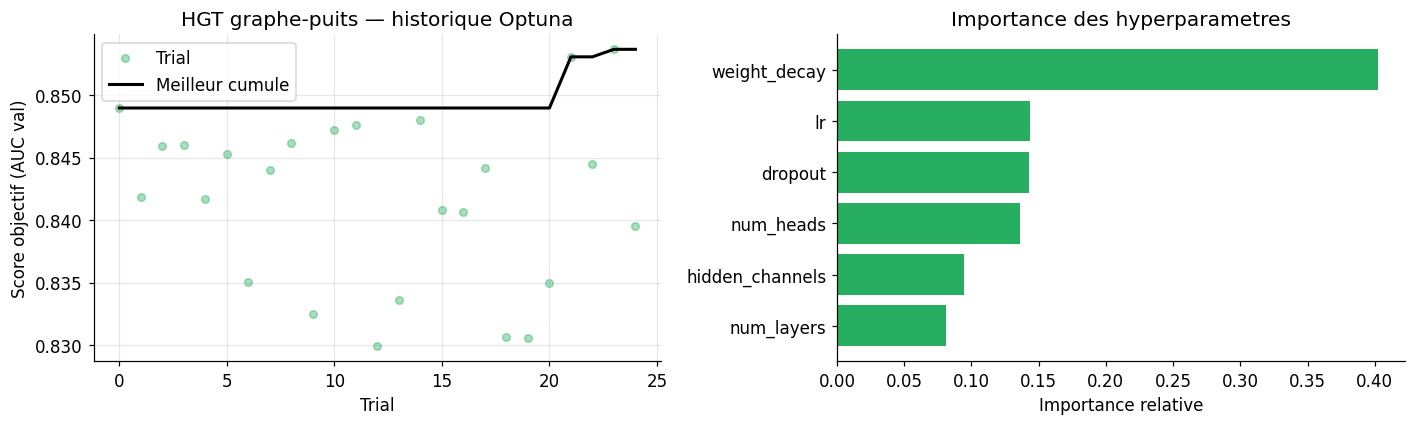

In [17]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_hgt(trial):
        m = HGT_Classifier(metadata,
            hidden_channels=trial.suggest_categorical("hidden_channels", [64, 128, 256]),
            num_heads=trial.suggest_categorical("num_heads", [2, 4]),
            num_layers=trial.suggest_int("num_layers", 1, 3),
            dropout=trial.suggest_float("dropout", 0.1, 0.5)).to(device)
        _, h = train_hgt(m, data, epochs=max(60, EPOCHS_HGT//2),
                         lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
                         weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
                         es_patience=30, verbose=False)
        return max(h["val_auc"])
    study_hgt = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_hgt.enqueue_trial({"hidden_channels": 128, "num_heads": 4, "num_layers": 2,
                             "dropout": 0.3, "lr": 3e-3, "weight_decay": 1e-5})
    study_hgt.optimize(objective_hgt, n_trials=_TRIALS["hgt"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    bp = study_hgt.best_params
    print("Meilleurs params HGT :", bp)
    optuna_history_fig(study_hgt, "HGT graphe-puits", "fig05_optuna_hgt.png", color="#27ae60")

  epoch   1/300 | loss 0.7005 | val_auc 0.6304 | val_f1 0.5719
  epoch  10/300 | loss 0.5210 | val_auc 0.7931 | val_f1 0.7008
  epoch  20/300 | loss 0.4170 | val_auc 0.8248 | val_f1 0.7159
  epoch  30/300 | loss 0.3549 | val_auc 0.8233 | val_f1 0.7339
  epoch  40/300 | loss 0.3106 | val_auc 0.8262 | val_f1 0.7256
  epoch  50/300 | loss 0.2894 | val_auc 0.8237 | val_f1 0.7256
  epoch  60/300 | loss 0.2730 | val_auc 0.8247 | val_f1 0.7346
  epoch  70/300 | loss 0.2683 | val_auc 0.8188 | val_f1 0.7309
  early stop epoch 76 (pas d'amelioration depuis 50 epochs)
Termine — meilleur val AUC : 0.8310


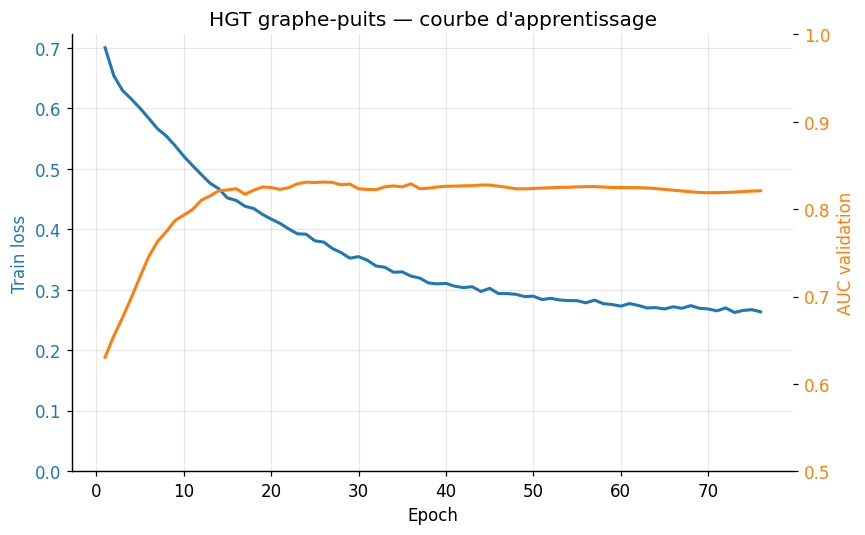

In [18]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model = HGT_Classifier(metadata, hidden_channels=bp["hidden_channels"],
        num_heads=bp["num_heads"], num_layers=bp["num_layers"], dropout=bp["dropout"]).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = hgt_model(_xd, _ed)
    hgt_model, hgt_hist = train_hgt(hgt_model, data, epochs=EPOCHS_HGT,
        lr=bp["lr"], weight_decay=bp["weight_decay"], verbose=True)

    ep = range(1, len(hgt_hist["train_loss"])+1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(ep, hgt_hist["train_loss"], color="tab:blue", lw=2, label="Train loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(alpha=.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.plot(ep, hgt_hist["val_auc"], color="tab:orange", lw=2, label="Val AUC")
    ax2.set_ylabel("AUC validation", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.set_ylim(0.5, 1.0); ax1.set_title("HGT graphe-puits — courbe d'apprentissage")
    plt.tight_layout(); savefig(fig, "fig06_hgt_learning_curve.png"); plt.show()

────────────────────────────────────────────────────
  HGT graphe-puits
────────────────────────────────────────────────────
  roc_auc             : 0.8770
  avg_precision       : 0.8610
  recall              : 0.7315
  precision           : 0.7871
  f1                  : 0.7582
  balanced_accuracy   : 0.7886
  accuracy            : 0.7956


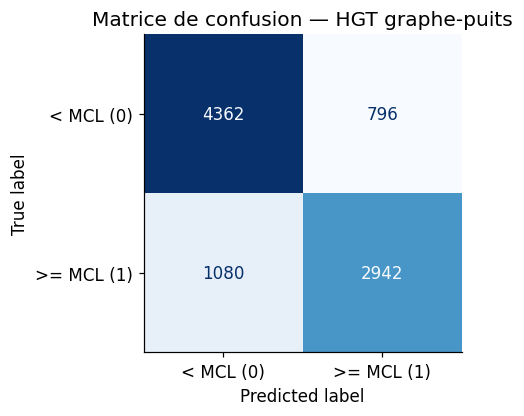

In [19]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model.eval()
    with torch.no_grad():
        xd, ed = graph_tensors(data)
        proba_all = F.softmax(hgt_model(xd, ed), dim=1)[:, 1].cpu().numpy()
    y_proba_hgt = proba_all[idx_test]
    y_pred_hgt  = (y_proba_hgt > 0.5).astype(int)
    m_hgt = evaluate("HGT graphe-puits", y_test, y_pred_hgt, y_proba_hgt)
    plot_confusion("HGT graphe-puits", y_test, y_pred_hgt, "fig07_hgt_confusion.png")

## Modèle 4 — Embedding Fusion (features + embeddings HGT → XGBoost)

Embeddings HGT 192D -> PCA 48D (variance 95.3%)


  0%|          | 0/20 [00:00<?, ?it/s]

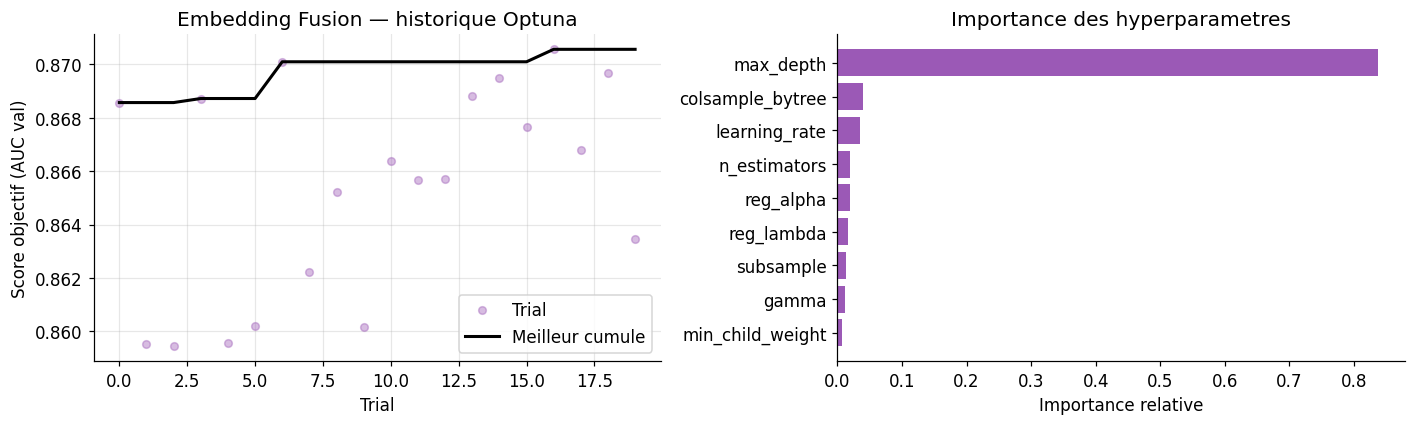

────────────────────────────────────────────────────
  Embedding Fusion
────────────────────────────────────────────────────
  roc_auc             : 0.9079
  avg_precision       : 0.8955
  recall              : 0.7663
  precision           : 0.8285
  f1                  : 0.7962
  balanced_accuracy   : 0.8213
  accuracy            : 0.8281


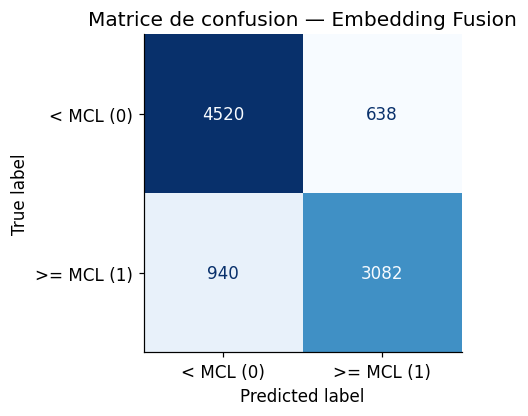

In [20]:
if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad():
        emb_all = hgt_model(xd, ed, return_embeddings=True).cpu().numpy()
    pca_fus = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(emb_all[idx_train])
    emb_p = pca_fus.transform(emb_all)
    n_emb = emb_p.shape[1]
    print(f"Embeddings HGT {emb_all.shape[1]}D -> PCA {n_emb}D "
          f"(variance {pca_fus.explained_variance_ratio_.sum():.1%})")

    X_fus = np.concatenate([X_all_proc, emb_p], axis=1)
    Xtr_fus, Xva_fus, Xte_fus = (X_fus[i] for i in (idx_train, idx_val, idx_test))
    fusion_names = proc_cols + [f"HGT_emb_{j}" for j in range(n_emb)]

    def objective_fusion(trial):
        p = dict(n_estimators=trial.suggest_int("n_estimators", 150, 800),
                 max_depth=trial.suggest_int("max_depth", 3, 12),
                 learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 subsample=trial.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                 min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
                 gamma=trial.suggest_float("gamma", 0.0, 1.0),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
                 scale_pos_weight=scale_pos, tree_method="hist",
                 random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
        c = xgb.XGBClassifier(**p, early_stopping_rounds=40)
        c.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
        return roc_auc_score(y_val, c.predict_proba(Xva_fus)[:, 1])

    study_fus = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_fus.optimize(objective_fusion, n_trials=_TRIALS["fusion"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    optuna_history_fig(study_fus, "Embedding Fusion", "fig08_optuna_fusion.png", color="#9b59b6")

    p_fus = {**study_fus.best_params, "scale_pos_weight": scale_pos, "tree_method": "hist",
             "random_state": RANDOM_STATE, "eval_metric": "auc", "verbosity": 0}
    xgb_fusion = xgb.XGBClassifier(**p_fus, early_stopping_rounds=50)
    xgb_fusion.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
    y_pred_fus  = xgb_fusion.predict(Xte_fus)
    y_proba_fus = xgb_fusion.predict_proba(Xte_fus)[:, 1]
    m_fus = evaluate("Embedding Fusion", y_test, y_pred_fus, y_proba_fus)
    plot_confusion("Embedding Fusion", y_test, y_pred_fus, "fig09_fusion_confusion.png")

## Modèle 5 — Stacking honnête (méta-modèle ajusté sur la validation)

Correlation des predictions test (RF/XGB/HGT) :
        RF    XGB    HGT
RF   1.000  0.962  0.784
XGB  0.962  1.000  0.834
HGT  0.784  0.834  1.000

Poids du meta-modele (RF, XGB, HGT) : [0.124 0.609 0.081]
────────────────────────────────────────────────────
  Stacking
────────────────────────────────────────────────────
  roc_auc             : 0.9093
  avg_precision       : 0.8937
  recall              : 0.7626
  precision           : 0.8505
  f1                  : 0.8041
  balanced_accuracy   : 0.8290
  accuracy            : 0.8373


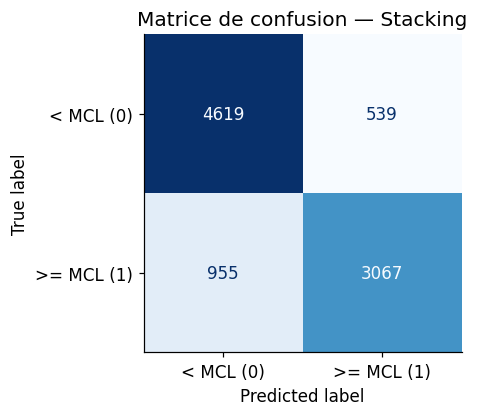


Moyenne ponderee (poids val [0.2 0.7 0.1]) — AUC test : 0.9086


In [21]:
if TORCH_GEOMETRIC_AVAILABLE:
    P_val  = np.column_stack([rf.predict_proba(X_val_proc)[:, 1],
                              xgb_model.predict_proba(X_val_proc)[:, 1],
                              proba_all[idx_val]])
    P_test = np.column_stack([y_proba_rf, y_proba_xgb, y_proba_hgt])

    corr = np.corrcoef(P_test.T)
    print("Correlation des predictions test (RF/XGB/HGT) :")
    print(pd.DataFrame(corr, index=["RF","XGB","HGT"], columns=["RF","XGB","HGT"]).round(3).to_string())

    eps = 1e-6
    logit = lambda p: np.log((p + eps) / (1 - p + eps))
    meta_lr = LogisticRegression(max_iter=1000).fit(logit(P_val), y_val)
    y_proba_stk = meta_lr.predict_proba(logit(P_test))[:, 1]
    y_pred_stk = (y_proba_stk > 0.5).astype(int)
    print("\nPoids du meta-modele (RF, XGB, HGT) :", np.round(meta_lr.coef_[0], 3))
    m_stk = evaluate("Stacking", y_test, y_pred_stk, y_proba_stk)
    plot_confusion("Stacking", y_test, y_pred_stk, "fig10_stacking_confusion.png")

    best_w, best_auc = None, 0
    for w1 in np.linspace(0, 1, 21):
        for w2 in np.linspace(0, 1 - w1, int(21*(1-w1))+1):
            w = np.array([w1, w2, 1 - w1 - w2])
            auc = roc_auc_score(y_val, P_val @ w)
            if auc > best_auc:
                best_auc, best_w = auc, w
    print(f"\nMoyenne ponderee (poids val {np.round(best_w,2)}) — "
          f"AUC test : {roc_auc_score(y_test, P_test @ best_w):.4f}")

## Comparaison finale

                  ROC-AUC      AP  Rappel  Precision      F1  Bal.Acc  Accuracy
Modele                                                                         
HGT graphe-puits   0.8770  0.8610  0.7315     0.7871  0.7582   0.7886    0.7956
Random Forest      0.8910  0.8763  0.7280     0.8589  0.7881   0.8174    0.8284
XGBoost            0.9059  0.8911  0.7541     0.8484  0.7985   0.8245    0.8332
Embedding Fusion   0.9079  0.8955  0.7663     0.8285  0.7962   0.8213    0.8281
Stacking           0.9093  0.8937  0.7626     0.8505  0.8041   0.8290    0.8373

Meilleur modele (AUC) : Stacking  (AUC=0.9093)
Rappel NB11 (graphe echantillons) : HGT 0.8425 | RF 0.8910 | XGB 0.9059 | Fusion 0.8808 | Stacking 0.9061


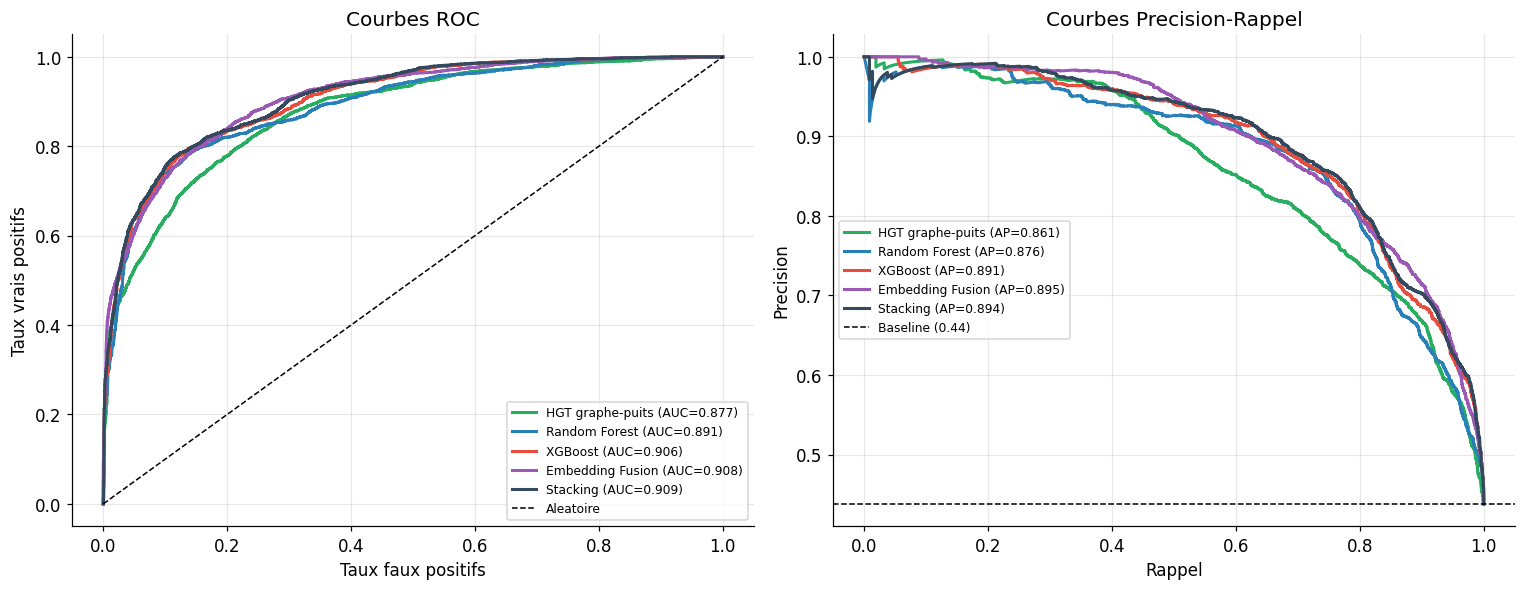

In [22]:
ORDER = ["HGT graphe-puits", "Random Forest", "XGBoost", "Embedding Fusion", "Stacking"]
ORDER = [m for m in ORDER if m in RESULTS]
COLORS = {"HGT graphe-puits": "#27ae60", "Random Forest": "#2980b9", "XGBoost": "#e74c3c",
          "Embedding Fusion": "#9b59b6", "Stacking": "#34495e"}

comp = pd.DataFrame([{
    "Modele": m,
    "ROC-AUC": RESULTS[m]["metrics"]["roc_auc"],
    "AP": RESULTS[m]["metrics"]["avg_precision"],
    "Rappel": RESULTS[m]["metrics"]["recall"],
    "Precision": RESULTS[m]["metrics"]["precision"],
    "F1": RESULTS[m]["metrics"]["f1"],
    "Bal.Acc": RESULTS[m]["metrics"]["balanced_accuracy"],
    "Accuracy": RESULTS[m]["metrics"]["accuracy"],
} for m in ORDER]).set_index("Modele")
comp.to_csv(RES_DIR / "comparaison_modeles.csv")
print(comp.round(4).to_string())
best = comp["ROC-AUC"].idxmax()
print(f"\nMeilleur modele (AUC) : {best}  (AUC={comp.loc[best,'ROC-AUC']:.4f})")
print("Rappel NB11 (graphe echantillons) : HGT 0.8425 | RF 0.8910 | XGB 0.9059 | "
      "Fusion 0.8808 | Stacking 0.9061")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
prev = y_test.mean()
for m in ORDER:
    pr = RESULTS[m]["y_proba"]; c = COLORS[m]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax1.plot(fpr, tpr, lw=2, color=c, label=f"{m} (AUC={RESULTS[m]['metrics']['roc_auc']:.3f})")
    p, r, _ = precision_recall_curve(y_test, pr)
    ax2.plot(r, p, lw=2, color=c, label=f"{m} (AP={RESULTS[m]['metrics']['avg_precision']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire")
ax2.axhline(prev, color="k", ls="--", lw=1, label=f"Baseline ({prev:.2f})")
ax1.set(xlabel="Taux faux positifs", ylabel="Taux vrais positifs", title="Courbes ROC")
ax2.set(xlabel="Rappel", ylabel="Precision", title="Courbes Precision-Rappel")
ax1.legend(fontsize=8); ax2.legend(fontsize=8); ax1.grid(alpha=.3); ax2.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig11_roc_pr_all.png"); plt.show()

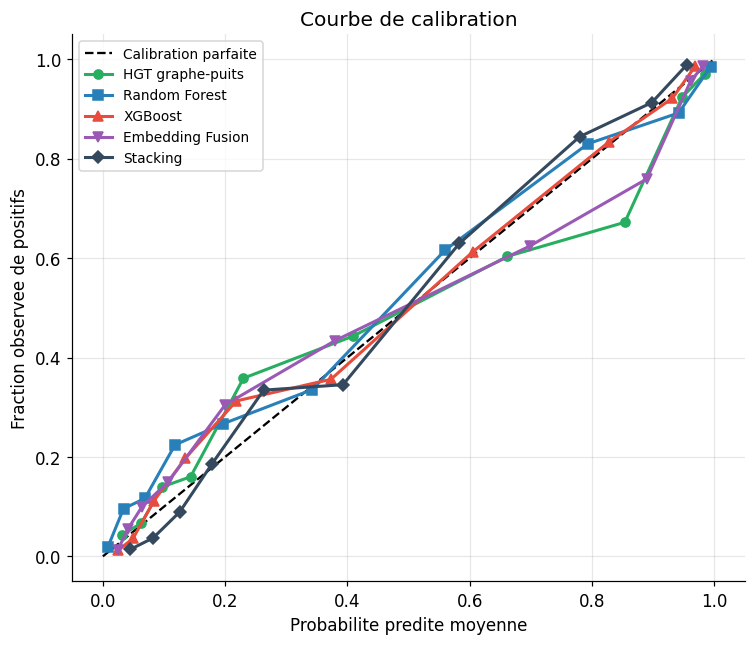

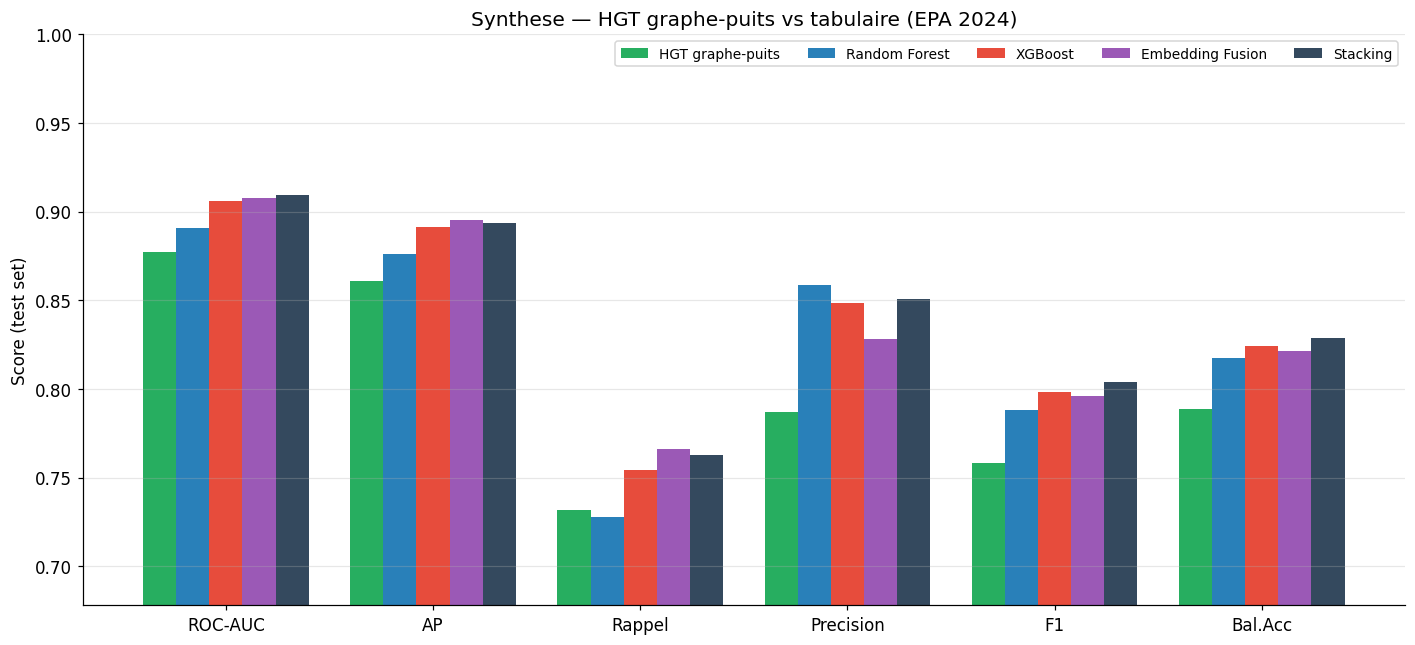

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
for m, mk in zip(ORDER, ["o-", "s-", "^-", "v-", "D-"]):
    fr, mp = calibration_curve(y_test, RESULTS[m]["y_proba"], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, mk, color=COLORS[m], lw=2, label=m)
ax.set(xlabel="Probabilite predite moyenne", ylabel="Fraction observee de positifs",
       title="Courbe de calibration")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig12_calibration_all.png"); plt.show()

metrics = ["roc_auc", "avg_precision", "recall", "precision", "f1", "balanced_accuracy"]
labels = ["ROC-AUC", "AP", "Rappel", "Precision", "F1", "Bal.Acc"]
x = np.arange(len(labels)); w = 0.8 / len(ORDER)
fig, ax = plt.subplots(figsize=(13, 6))
for i, m in enumerate(ORDER):
    vals = [RESULTS[m]["metrics"][k] for k in metrics]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=m, color=COLORS[m])
allv = [RESULTS[m]["metrics"][k] for m in ORDER for k in metrics]
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(max(0, min(allv) - 0.05), 1.0)
ax.set_ylabel("Score (test set)"); ax.set_title("Synthese — HGT graphe-puits vs tabulaire (EPA 2024)")
ax.legend(fontsize=9, ncol=len(ORDER)); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "fig13_dashboard.png"); plt.show()

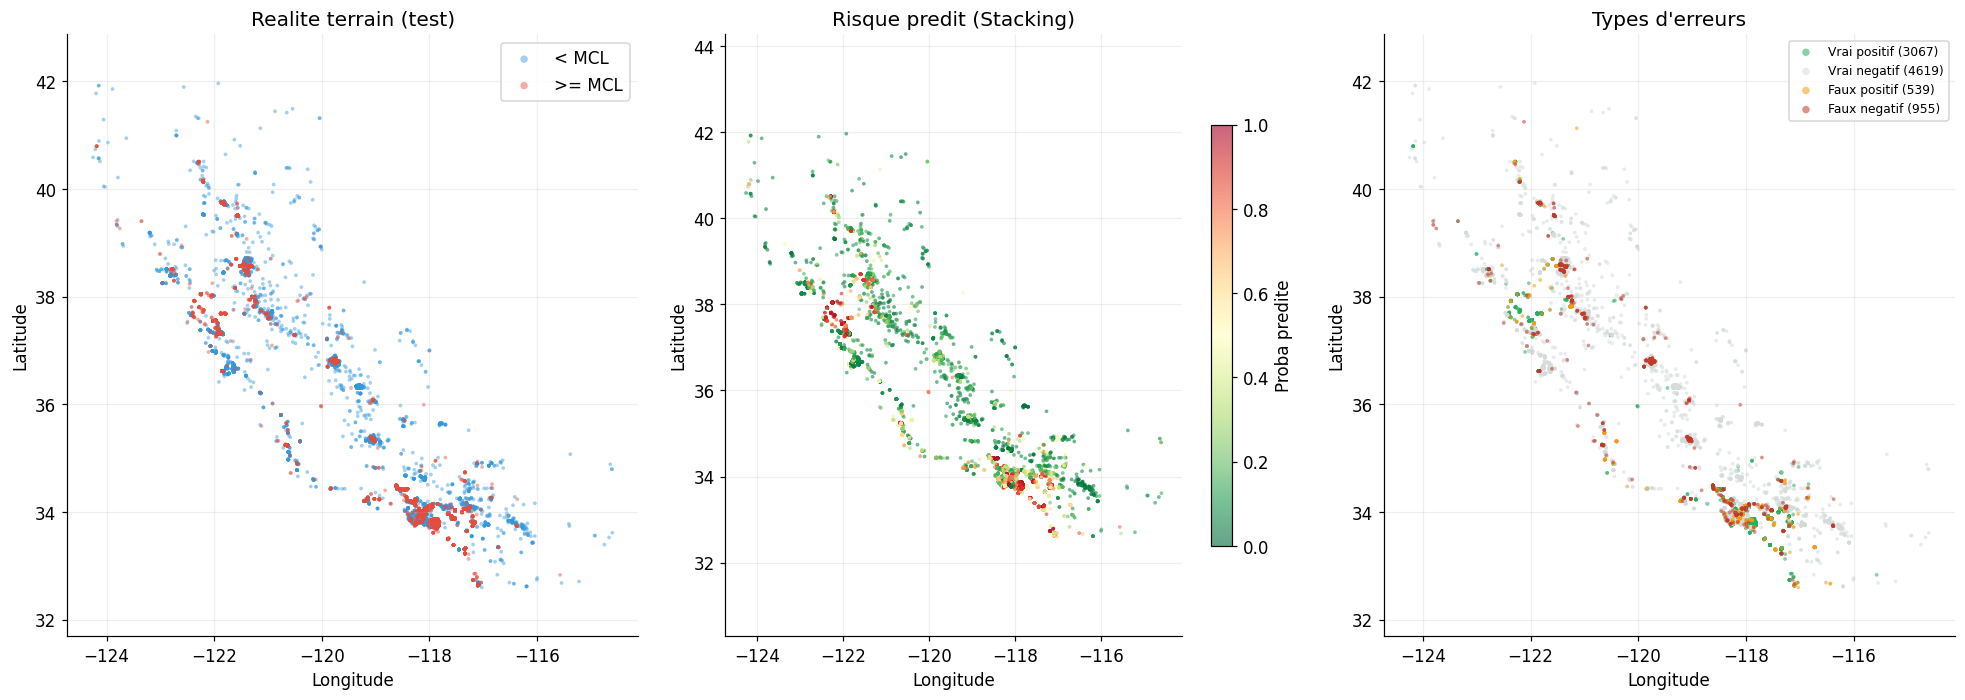

In [24]:
if {"latitude", "longitude"}.issubset(df.columns):
    coords = df.iloc[idx_test][["longitude", "latitude"]].copy()
    coords["y_true"] = y_test
    coords["proba"]  = RESULTS[best]["y_proba"]
    coords["y_pred"] = RESULTS[best]["y_pred"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    for lab, c, mlab in [(0, "#3498db", "< MCL"), (1, "#e74c3c", ">= MCL")]:
        s = coords[coords.y_true == lab]
        axes[0].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.45, label=mlab, edgecolors="none")
    axes[0].set_title("Realite terrain (test)"); axes[0].legend(markerscale=2)
    sc = axes[1].scatter(coords.longitude, coords.latitude, s=6, c=coords.proba,
                         cmap="RdYlGn_r", vmin=0, vmax=1, alpha=.6, edgecolors="none")
    plt.colorbar(sc, ax=axes[1], shrink=.7, label="Proba predite")
    axes[1].set_title(f"Risque predit ({best})")
    conds = [(coords.y_true==1)&(coords.y_pred==1), (coords.y_true==0)&(coords.y_pred==0),
             (coords.y_true==0)&(coords.y_pred==1), (coords.y_true==1)&(coords.y_pred==0)]
    labs = ["Vrai positif", "Vrai negatif", "Faux positif", "Faux negatif"]
    coords["err"] = np.select(conds, labs, default="?")
    pal = {"Vrai positif":"#27ae60","Vrai negatif":"#d5dbdb","Faux positif":"#f39c12","Faux negatif":"#c0392b"}
    for cat, c in pal.items():
        s = coords[coords.err == cat]
        axes[2].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.55, label=f"{cat} ({len(s)})", edgecolors="none")
    axes[2].set_title("Types d'erreurs"); axes[2].legend(markerscale=2, fontsize=8)
    for ax in axes:
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_aspect("equal", "datalim"); ax.grid(alpha=.2)
    plt.tight_layout(); savefig(fig, "fig14_map_predictions.png"); plt.show()

## Évaluation honnête — CV spatiale par blocs (optionnelle, `RUN_SPATIAL_CV=True`)

NB : les deux features spatiales étiquetées ne sont pas recalculées par fold ici (elles
utiliseraient des puits du bloc test) — cette section les exclut pour rester honnête.

In [25]:
if RUN_SPATIAL_CV and {"latitude", "longitude"}.issubset(df.columns):
    yall = df["target"].values
    blocks = KMeans(SPATIAL_CV_K, random_state=RANDOM_STATE, n_init=10).fit_predict(
        StandardScaler().fit_transform(df[["latitude", "longitude"]].values))
    print("Tailles des blocs spatiaux :", np.bincount(blocks))
    rows = []
    for f in range(SPATIAL_CV_K):
        te = blocks == f; tr = ~te
        if te.sum() < 50 or len(np.unique(yall[te])) < 2:
            continue
        ct = ColumnTransformer([
            ("num", Pipeline([("im", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([("im", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("en", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=-1, encoded_missing_value=-1))]), cat_cols)])
        Xtr, Xte = ct.fit_transform(df.loc[tr, feature_names]), ct.transform(df.loc[te, feature_names])
        ytr, yte = yall[tr], yall[te]
        spw = (ytr == 0).sum() / max(1, (ytr == 1).sum())
        for name_, mdl in [
            ("XGBoost", xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")),
            ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                n_jobs=-1, random_state=RANDOM_STATE))]:
            mdl.fit(Xtr, ytr); p = mdl.predict_proba(Xte)[:, 1]
            rows.append(dict(model=name_, fold=f, n_test=int(te.sum()),
                             prev=float(yte.mean()), AUC=roc_auc_score(yte, p),
                             AP=average_precision_score(yte, p)))
        print(f"  fold {f} ok (n_test={int(te.sum())}, prev={yte.mean():.2f})")
    cv_sp = pd.DataFrame(rows)
    cv_sp.to_csv(RES_DIR / "cv_spatiale.csv", index=False)
    print(cv_sp.groupby("model").agg(AUC_moy=("AUC", "mean"), AUC_std=("AUC", "std"),
                                     AP_moy=("AP", "mean")).round(4).to_string())
else:
    print("CV spatiale desactivee (RUN_SPATIAL_CV=False).")

Tailles des blocs spatiaux : [ 4886 15740  3411  6414  2637  3517  8037  1696]
  fold 0 ok (n_test=4886, prev=0.30)
  fold 1 ok (n_test=15740, prev=0.61)
  fold 2 ok (n_test=3411, prev=0.23)
  fold 3 ok (n_test=6414, prev=0.40)
  fold 4 ok (n_test=2637, prev=0.39)
  fold 5 ok (n_test=3517, prev=0.22)
  fold 6 ok (n_test=8037, prev=0.53)
  fold 7 ok (n_test=1696, prev=0.43)
               AUC_moy  AUC_std  AP_moy
model                                  
Random Forest   0.6335   0.0484  0.5279
XGBoost         0.6425   0.0473  0.5258


In [26]:
summary = {
    "notebook": "12 — HGT transductif sur graphe puits",
    "target": "EPA 2024 NPDWR (MCL individuels + Indice de Risque melange)",
    "dataset": {"n_total": int(len(df)), "n_wells": int(n_wells), "n_features": len(proc_cols)},
    "split": {"mode": "group_by_well" if GROUP_SPLIT_BY_WELL else "random_stratified",
              "train": int(len(idx_train)), "val": int(len(idx_val)), "test": int(len(idx_test))},
    "config": {"OPTUNA_MODE": OPTUNA_MODE, "EPOCHS_HGT": EPOCHS_HGT,
               "WELL_KNN_K": WELL_KNN_K, "WELL_BANDS_KM": list(WELL_BANDS_KM),
               "SOURCE_BANDS_KM": list(SOURCE_BANDS_KM),
               "ADD_SPATIAL_LABEL_FEATURES": ADD_SPATIAL_LABEL_FEATURES,
               "hgt_best_params": bp if TORCH_GEOMETRIC_AVAILABLE else None},
    "results": {m: {k: round(float(v), 4) for k, v in RESULTS[m]["metrics"].items() if k != "name"}
                for m in RESULTS},
    "best_model_auc": best,
    "nb11_reference": {"HGT": 0.8425, "RF": 0.8910, "XGB": 0.9059,
                       "Fusion": 0.8808, "Stacking": 0.9061},
}
with open(RES_DIR / "synthese_resultats.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

with open(MODELS_DIR / "random_forest.pkl", "wb") as f: pickle.dump(rf, f)
with open(MODELS_DIR / "xgboost.pkl", "wb") as f: pickle.dump(xgb_model, f)
with open(MODELS_DIR / "preprocessor.pkl", "wb") as f: pickle.dump(preprocessor, f)
with open(MODELS_DIR / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({"state_dict": hgt_model.state_dict(), "metadata": data.metadata(),
                "params": bp}, MODELS_DIR / "hgt_graphe_puits.pt")
    with open(MODELS_DIR / "xgb_fusion.pkl", "wb") as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR / "meta_lr.pkl", "wb") as f: pickle.dump(meta_lr, f)
print("Artefacts sauvegardes dans", OUT_DIR.resolve())
print("Resultats :", json.dumps(summary["results"], indent=2, ensure_ascii=False))

zip_path = Path(f"PFAS_HGT_graphe_puits_outputs_{time.strftime('%Y%m%d_%H%M')}.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (FIG_DIR, RES_DIR):
        for p in folder.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to(OUT_DIR))
print(f"Archive creee : {zip_path}  ({zip_path.stat().st_size/1e6:.1f} Mo)")
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

Artefacts sauvegardes dans /content/outputs_notebook_graphe_puits
Resultats : {
  "Random Forest": {
    "roc_auc": 0.891,
    "avg_precision": 0.8763,
    "accuracy": 0.8284,
    "balanced_accuracy": 0.8174,
    "precision": 0.8589,
    "recall": 0.728,
    "f1": 0.7881
  },
  "XGBoost": {
    "roc_auc": 0.9059,
    "avg_precision": 0.8911,
    "accuracy": 0.8332,
    "balanced_accuracy": 0.8245,
    "precision": 0.8484,
    "recall": 0.7541,
    "f1": 0.7985
  },
  "HGT graphe-puits": {
    "roc_auc": 0.877,
    "avg_precision": 0.861,
    "accuracy": 0.7956,
    "balanced_accuracy": 0.7886,
    "precision": 0.7871,
    "recall": 0.7315,
    "f1": 0.7582
  },
  "Embedding Fusion": {
    "roc_auc": 0.9079,
    "avg_precision": 0.8955,
    "accuracy": 0.8281,
    "balanced_accuracy": 0.8213,
    "precision": 0.8285,
    "recall": 0.7663,
    "f1": 0.7962
  },
  "Stacking": {
    "roc_auc": 0.9093,
    "avg_precision": 0.8937,
    "accuracy": 0.8373,
    "balanced_accuracy": 0.829,
    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>